# Exploratory Data Analysis of MOEX Futures Market Trades in 2025
### Liquidity, Volatility and Open Interest

## 1. Abstract / Annotation

This project presents an exploratory data analysis (EDA) of **trade-level data from
the Moscow Exchange (MOEX) derivatives market (FORTS)** for the **2025 trading year**.
Starting from the raw monthly trade files (`fut_deal`), which together contain
**403,559,610 individual futures trades** (≈25–43 million per month), we built a
reproducible pipeline that streams the compressed `.7z` archives in memory-safe
chunks, validates data quality, and aggregates the tick-level trades into a clean
**daily dataset** (one row per contract per day with OHLC prices, traded volume,
number of trades, open interest, and a buy/sell breakdown). On top of this dataset we
engineer return, volatility, range, liquidity and order-flow features and study
**seven liquid "perpetual" futures** that span several asset classes (an equity index,
three FX rates, gold, and two single-stock contracts). *In this project we do not
estimate theoretical derivative prices. The goal is exploratory data analysis of
actual futures trade data: price dynamics, trading volume, number of trades, open
interest, volatility and buy/sell activity.*

The report covers descriptive statistics, comparative visualisations, and three
hypotheses. The main findings are: **(H1)** across the universe of contracts, liquidity
and volatility are essentially **uncorrelated** — the "more liquid ⇒ less volatile"
hypothesis is **not supported** by these data; **(H2)** days with large price moves
show **markedly higher** trading activity (**supported**, p ≈ 5·10⁻³¹); and **(H3)**
the buy/sell imbalance is **modestly higher** on high-volatility days (**supported**,
p ≈ 0.006). A notable data-driven side finding is that **MOEX weekend trading sessions**
appear in the data from mid-August 2025 for equity/index/metal instruments but not for
FX instruments. **Team contributions** (replace placeholders with real names):
*Team member 1* — data acquisition, chunked pipeline and cleaning; *Team member 2* —
feature engineering and descriptive statistics; *Team member 3* — visualisations and
hypothesis testing; *Team member 4* — Streamlit and FastAPI interfaces and report
writing.

## 2. Dataset Description

**Subject area.** The data come from the **MOEX derivatives market (FORTS / срочный
рынок)** — the segment where futures and options on Russian financial instruments are
traded. We use only the **futures trade files** (`fut_deal`); options are out of scope.
The data were obtained as twelve monthly `7z` archives (`202501_fut_deal.7z` …
`202512_fut_deal.7z`, ≈145–251 MB compressed each, ≈1.5–2.6 GB uncompressed each) and
were **downloaded, decompressed, validated and aggregated by us** — i.e. the analytical
dataset is *self-built from raw exchange trades*, not a ready-made table.

**Original dataset — one row = one executed trade.** 8 fields:

| Field | Type | Meaning |
|---|---|---|
| `#SYMBOL` | string | Futures contract code (ticker) |
| `SYSTEM` | string | Trading system marker (constant `F`) |
| `MOMENT` | int (17 digits) | Trade timestamp `YYYYMMDDHHMMSSmmm` |
| `ID_DEAL` | int64 | Unique trade identifier |
| `PRICE_DEAL` | float | Trade price |
| `VOLUME` | int | Trade size (contracts) |
| `OPEN_POS` | int | Open interest after the trade |
| `DIRECTION` | string | Aggressor side: `B` (buy) or `S` (sell) |

**Aggregated dataset — one row = one contract on one trading day** (built by us). Base
fields: `date`, `symbol`, `open_price`, `high_price`, `low_price`, `close_price`,
`avg_price`, `total_volume`, `num_trades`, `mean_open_pos`, `max_open_pos`,
`buy_volume`, `sell_volume`, `buy_count`, `sell_count`. The full-year aggregated table
has **86,489 rows across 947 contracts** spanning **2024-12-30 → 2025-12-30**.

**Data quality.** The raw data are remarkably clean: across all 12 months there are
**0 missing values** in any column, **0 duplicate `ID_DEAL`**, **no non-positive
prices, no non-positive volumes, and no negative open interest**. `DIRECTION` only ever
takes `B`/`S`; `SYSTEM` is always `F`. The only non-obvious points, both handled
explicitly, are: (1) each monthly file starts with the **evening session of the
previous month's last trading day** (e.g. the January file begins on 2024-12-30
19:05), so the real date coverage extends slightly before each month; and (2) the
exchange runs **weekend sessions** for some instruments from 2025-08-16 onward. No
"wrong types" needed fixing — we read each column with an explicit dtype and parsed
`MOMENT` into a proper `datetime`.

## 3. Data Loading

We load the self-built aggregated datasets (Parquet) and the per-month data-quality reports produced by the pipeline. The raw 404M-trade files are **never** loaded into memory here — they were processed in chunks by `scripts/aggregate_fut_deal.py`.

In [1]:
import os, sys, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.join('..', 'scripts'))
sys.path.insert(0, os.path.join(os.getcwd(), 'scripts'))
import analysis_lib as A

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

daily_all = A.load_daily_all()       # all 947 contracts, one row per contract-day
df         = A.load_analysis()       # 7 selected perpetuals + engineered features
summary    = A.load_summary()        # per-#SYMBOL liquidity / quality metrics

print('daily_all:', daily_all.shape, '| contracts:', daily_all['symbol'].nunique())
print('analysis :', df.shape, '| instruments:', sorted(df['symbol'].unique()))
print('date range:', daily_all['date'].min().date(), '→', daily_all['date'].max().date())

daily_all: (86489, 15) | contracts: 947
analysis : (1905, 27) | instruments: ['CNYRUBF', 'EURRUBF', 'GAZPF', 'GLDRUBF', 'IMOEXF', 'SBERF', 'USDRUBF']
date range: 2024-12-30 → 2025-12-30


**Discussion.** Three tables drive the whole report: `daily_all` (the full contract universe, used for the broad liquidity-vs-volatility test), `df` (the seven selected instruments with engineered features, used for most plots and hypotheses), and `summary` (per-contract metrics used to *select* the instruments).

## 4. Initial Data Overview

In [2]:
# One row per trade in the ORIGINAL file (read only the first rows - file is ~1.6 GB)
raw_sample = pd.read_csv('../data/interim/202501_fut_deal.csv', nrows=5)
print('Original trade-level data (first 5 rows):')
display(raw_sample)
print('Original columns:', list(raw_sample.columns))

Original trade-level data (first 5 rows):


,#SYMBOL,SYSTEM,MOMENT,ID_DEAL,PRICE_DEAL,VOLUME,OPEN_POS,DIRECTION
0,NGF5,F,20241230190500000,2012577080260165633,4.0750,10,415480,S
1,NGF5,F,20241230190500000,2012577080260165634,4.0730,10,415480,S
2,NGF5,F,20241230190500000,2012577080260165635,4.0700,25,415500,S
3,NGF5,F,20241230190500000,2012577080260165636,4.0700,1,415500,S
4,NGF5,F,20241230190500000,2012577080260165637,4.0700,1,415500,S


Original columns: ['#SYMBOL', 'SYSTEM', 'MOMENT', 'ID_DEAL', 'PRICE_DEAL', 'VOLUME', 'OPEN_POS', 'DIRECTION']


In [3]:
# One row per contract-day in our AGGREGATED dataset
print('Aggregated daily data (head):')
display(daily_all.head())
print('\nDtypes:'); print(daily_all.dtypes)

Aggregated daily data (head):


,date,symbol,open_price,high_price,low_price,close_price,avg_price,total_volume,num_trades,mean_open_pos,max_open_pos,buy_volume,sell_volume,buy_count,sell_count
0,2025-10-28,AAH6,65.9100,66.2200,65.9100,66.2200,66.0650,2,2,3.0000,4,2,0,2,0
1,2025-10-29,AAH6,66.1200,66.1200,64.9500,64.9500,65.7220,5,5,10.0000,14,0,5,0,5
2,2025-10-30,AAH6,64.3000,65.4800,64.3000,65.4800,65.1883,6,6,21.0000,26,5,1,5,1
3,2025-10-31,AAH6,64.4400,67.1400,62.6500,64.2600,64.8200,21,17,23.2941,30,12,9,9,8
4,2025-11-03,AAH6,63.9400,64.7000,63.7500,63.7500,63.9483,9,6,27.0000,30,1,8,1,5



Dtypes:
date             datetime64[us]
symbol                   string
open_price              float64
high_price              float64
low_price               float64
close_price             float64
avg_price               float64
total_volume              int64
num_trades                int64
mean_open_pos           float64
max_open_pos              int64
buy_volume                int64
sell_volume               int64
buy_count                 int64
sell_count                int64
dtype: object


**Discussion.** The original file is genuine tick data — every executed trade with its price, size, post-trade open interest and aggressor side. Our aggregation turns those hundreds of millions of trades into a compact, analysis-ready daily table while preserving intraday extremes (high/low) and order-flow (buy/sell split).

## 5. Data Quality Check

We summarise the per-month quality reports emitted by the pipeline and verify cleanliness directly on the aggregated table.

In [4]:
qfiles = sorted(glob.glob('../data/processed/quality_2025*.json'))
rows = []
for f in qfiles:
    q = json.load(open(f)); m = os.path.basename(f)[8:14]
    rows.append({'month': m, 'trades': q['rows'], 'symbols': q['n_unique_symbols'],
                 'nan_total': sum(q['nan_by_column'].values()),
                 'dup_ID_DEAL': q['n_id_deal_duplicates'],
                 'price<=0': q['price_le0'], 'vol<=0': q['volume_le0'],
                 'open_int<0': q['open_pos_lt0']})
qtab = pd.DataFrame(rows)
display(qtab)
print(f"TOTAL trades over the year: {qtab['trades'].sum():,}")
print('Missing values anywhere:', int(qtab['nan_total'].sum()))
print('Duplicate trade IDs anywhere:', int(qtab['dup_ID_DEAL'].sum()))
print('Invalid prices/volumes/open-interest anywhere:',
      int(qtab[['price<=0','vol<=0','open_int<0']].to_numpy().sum()))

,month,trades,symbols,nan_total,dup_ID_DEAL,price<=0,vol<=0,open_int<0
0,202501,24668256,352,0,0,0,0,0
1,202502,34482345,364,0,0,0,0,0
2,202503,38850381,460,0,0,0,0,0
3,202504,39998327,354,0,0,0,0,0
4,202505,28737359,356,0,0,0,0,0
5,202506,30679215,432,0,0,0,0,0
6,202507,29048983,327,0,0,0,0,0
7,202508,26859902,348,0,0,0,0,0
8,202509,33992059,472,0,0,0,0,0
9,202510,42587960,372,0,0,0,0,0


TOTAL trades over the year: 403,559,610
Missing values anywhere: 0
Duplicate trade IDs anywhere: 0
Invalid prices/volumes/open-interest anywhere: 0


In [5]:
# Direct checks on the aggregated dataset
print('NaN per column in aggregated daily dataset:')
print(daily_all.isna().sum().to_string())
print('\nDuplicate (symbol, date) rows:', int(daily_all.duplicated(['symbol','date']).sum()))

# Weekend-trading discovery
ud = pd.Series(daily_all['date'].unique())
wknd = pd.to_datetime(ud)[pd.to_datetime(ud).dt.weekday >= 5].sort_values()
print('\nUnique trading dates:', ud.nunique(), '| of which weekend dates:', len(wknd))
print('First weekend session in the data:', wknd.min().date())

NaN per column in aggregated daily dataset:
date             0
symbol           0
open_price       0
high_price       0
low_price        0
close_price      0
avg_price        0
total_volume     0
num_trades       0
mean_open_pos    0
max_open_pos     0
buy_volume       0
sell_volume      0
buy_count        0
sell_count       0

Duplicate (symbol, date) rows: 0

Unique trading dates: 285 | of which weekend dates: 31
First weekend session in the data: 2025-08-16


**Discussion.** The exchange data are clean: **zero** missing values, **zero** duplicate trade IDs, and no impossible prices/volumes/open-interest across all **403,559,610** trades. Because the source is clean, our cleanup effort is minimal by design — the value we add is *constructing* the daily dataset and features. Two honest data nuances surface here: each month carries the prior day's evening session, and **weekend trading sessions appear from 2025-08-16** (visible as ~31 Saturday/Sunday dates).

## 6. Data Cleanup

With the source already clean, cleanup reduces to *proving* cleanliness and ensuring correct types. The pipeline already (a) read every column with an explicit dtype, (b) parsed `MOMENT` (`YYYYMMDDHHMMSSmmm`) into `datetime`, and (c) merged the few contract-days that appear in two monthly files at the month boundary.

In [6]:
# Proof of clean, correctly-typed aggregated data
assert daily_all.isna().sum().sum() == 0, 'unexpected NaNs'
assert daily_all.duplicated(['symbol','date']).sum() == 0, 'unexpected dup keys'
assert str(daily_all['date'].dtype).startswith('datetime'), 'date not datetime'
assert (daily_all[['open_price','high_price','low_price','close_price']] > 0).all().all()
assert (daily_all['total_volume'] > 0).all() and (daily_all['num_trades'] > 0).all()
print('All cleanliness assertions passed: no NaN, no duplicate keys, datetime dates,'
      ' strictly positive prices/volume/trades.')

All cleanliness assertions passed: no NaN, no duplicate keys, datetime dates, strictly positive prices/volume/trades.


**Discussion.** All assertions pass, so no rows are dropped or imputed. This is the 'data are already clean — here is the proof' path. The single transformation that *could* create duplicates (concatenating monthly files) is handled by a trade-weighted merge in `build_features.py`.

## 7. Feature Engineering / Data Transformation

From the base daily fields we derive features for the seven selected instruments:

| Feature | Definition |
|---|---|
| `daily_return` | % change of `close_price` within each `symbol` |
| `abs_return` | `|daily_return|` |
| `price_range` | `high_price − low_price` |
| `relative_range` | `price_range / close_price · 100` (%) |
| `volume_per_trade` | `total_volume / num_trades` |
| `buy_share` | `buy_volume / (buy_volume + sell_volume)` |
| `direction_imbalance` | `|buy_share − 0.5|` |
| `normalized_close` | `close_price / first_close_of_symbol · 100` |
| `month`, `weekday` | calendar parts of `date` |

Intraday parts (`hour`, `minute`) are **not** available after daily aggregation; we
compute an hourly profile separately from the raw January file in the detailed overview.

In [7]:
feat_cols = ['symbol','date','close_price','daily_return','abs_return',
             'relative_range','volume_per_trade','buy_share',
             'direction_imbalance','normalized_close']
display(df[feat_cols].head(8))
print('Engineered analysis dataset:', df.shape,
      '| instruments:', df['symbol'].nunique(),
      '| asset classes:', sorted(df['asset_class'].unique()))

,symbol,date,close_price,daily_return,abs_return,relative_range,volume_per_trade,buy_share,direction_imbalance,normalized_close
0,CNYRUBF,2024-12-30,13.7410,NaN,NaN,0.2474,20.3194,0.3588,0.1412,100.0000
1,CNYRUBF,2025-01-03,13.8090,0.4949,0.4949,1.0211,28.6359,0.4620,0.0380,100.4949
2,CNYRUBF,2025-01-06,13.6780,-0.9487,0.9487,1.7473,31.3517,0.4916,0.0084,99.5415
3,CNYRUBF,2025-01-08,13.6140,-0.4679,0.4679,1.2046,22.6995,0.4495,0.0505,99.0758
4,CNYRUBF,2025-01-09,13.6440,0.2204,0.2204,1.4512,33.1427,0.4789,0.0211,99.2941
5,CNYRUBF,2025-01-10,13.7510,0.7842,0.7842,1.0617,29.1566,0.4989,0.0011,100.0728
6,CNYRUBF,2025-01-13,13.8770,0.9163,0.9163,1.0809,38.6147,0.5323,0.0323,100.9897
7,CNYRUBF,2025-01-14,13.9550,0.5621,0.5621,0.8957,31.3289,0.4817,0.0183,101.5574


Engineered analysis dataset: (1905, 27) | instruments: 7 | asset classes: ['Currency (CNY/RUB)', 'Currency (EUR/RUB)', 'Currency (USD/RUB)', 'Equity (Gazprom)', 'Equity (Sberbank)', 'Index (MOEX Index)', 'Metal (Gold/RUB)']


**Discussion.** `daily_return`/`abs_return` capture price dynamics and volatility; `relative_range` is a scale-free intraday-range proxy; `volume_per_trade` and the `buy_share`/`direction_imbalance` pair describe liquidity texture and order-flow; `normalized_close` rebases every instrument to 100 so series on very different price scales can be compared on one chart.

## 8. Descriptive Statistics

We report mean, median and standard deviation (plus min/max and quartiles) for the key numeric fields — overall and per instrument.

In [8]:
display(A.describe_overall(df).round(4))

,count,mean,median,std,min,q25,q50,q75,max
close_price,"1,905.0000","1,900.7766",133.8300,"3,254.7746",10.6750,89.6300,133.8300,"2,746.0000","11,285.1000"
total_volume,"1,905.0000","484,937.4341","101,252.0000","828,579.7457",112.0000,"15,824.0000","101,252.0000","552,701.0000","5,874,791.0000"
num_trades,"1,905.0000","21,066.7622","14,150.0000","22,601.9050",35.0000,"3,102.0000","14,150.0000","32,599.0000","148,639.0000"
mean_open_pos,"1,905.0000","2,264,333.7227","936,259.8815","4,108,174.3406","51,793.9360","133,587.3063","936,259.8815","1,489,334.5485","16,271,703.8301"
daily_return,"1,898.0000",-0.0110,-0.0098,1.4154,-7.0299,-0.7137,-0.0098,0.6085,11.1608
abs_return,"1,898.0000",0.9683,0.6516,1.0321,0.0000,0.2796,0.6516,1.3172,11.1608
relative_range,"1,905.0000",1.8497,1.5416,1.2551,0.0000,1.0410,1.5416,2.3049,12.2170
volume_per_trade,"1,905.0000",14.4871,8.3826,15.9890,1.3777,5.0222,8.3826,15.2947,97.3265
buy_share,"1,905.0000",0.4919,0.4942,0.0659,0.0741,0.4602,0.4942,0.5250,1.0000
direction_imbalance,"1,905.0000",0.0463,0.0327,0.0476,0.0000,0.0140,0.0327,0.0621,0.5000


In [9]:
print('Per-instrument statistics for daily_return (%):')
display(A.describe_by_symbol(df, 'daily_return').round(4))
print('Per-instrument statistics for total_volume:')
display(A.describe_by_symbol(df, 'total_volume').round(1))

Per-instrument statistics for daily_return (%):


,mean,median,std,min,max
symbol,,,,,
IMOEXF,-0.0051,-0.0804,1.5180,-5.0655,7.5079
USDRUBF,-0.1008,-0.0683,0.9912,-4.6509,2.8868
CNYRUBF,-0.0743,0.0309,1.0563,-4.8253,3.1181
EURRUBF,-0.0511,0.0000,1.0413,-4.8594,2.9353
GLDRUBF,0.0952,0.0582,1.2321,-4.4574,4.8769
GAZPF,0.0036,-0.0816,2.2051,-7.0299,11.1608
SBERF,0.0352,0.0211,1.3683,-6.4880,6.8136


Per-instrument statistics for total_volume:


,mean,median,std,min,max
symbol,,,,,
IMOEXF,"731,038.2000","600,546.0000","510,779.7000",18975,3096824
USDRUBF,"152,733.4000","130,165.0000","80,588.6000",3698,470325
CNYRUBF,"2,146,997.8000","2,012,228.0000","1,050,069.0000",24749,5874791
EURRUBF,"9,598.5000","8,192.0000","5,549.6000",255,33250
GLDRUBF,"397,766.9000","368,129.0000","265,610.1000",2659,1787350
GAZPF,"30,507.3000","27,637.0000","19,310.8000",112,119528
SBERF,"15,869.1000","13,524.0000","12,604.7000",179,117911


**Discussion.** Mean daily returns are close to zero for all instruments (as expected for price changes), while the standard deviation of returns — our volatility proxy — is clearly larger for single-stock futures than for FX. Volume distributions are highly right-skewed (mean ≫ median), typical of trading activity with occasional very busy days.

## 9. Basic Visualizations

Four numeric fields, four chart types: line, histogram, scatter, box.

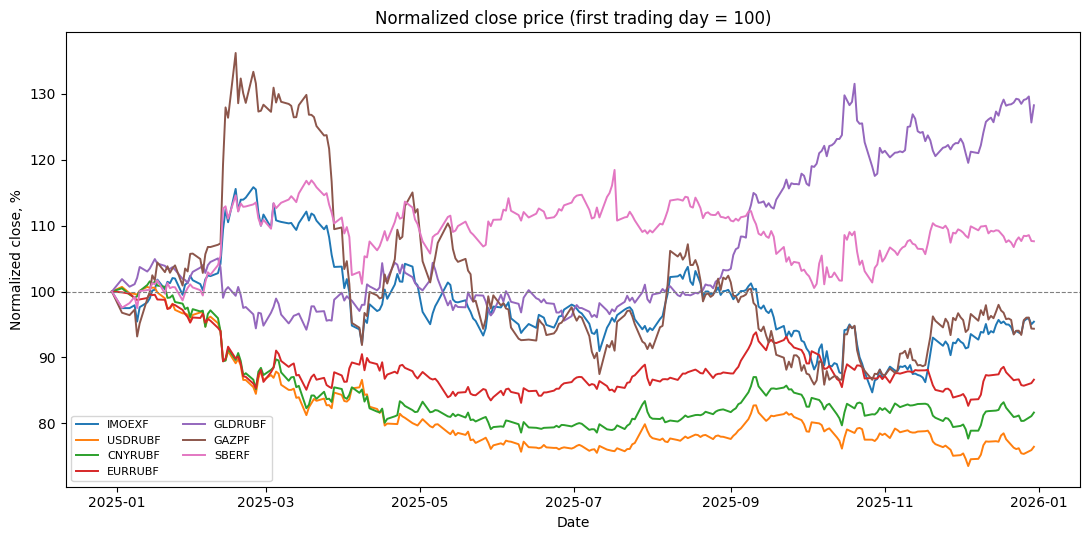

In [10]:
fig = A.fig_normalized_close(df); display(fig); plt.close(fig)

**What it shows.** Rebased to 100 on the first day, the instruments diverge over the year; equity/index lines move in a wider band than the FX lines, a first visual hint that equities are more volatile than currencies.

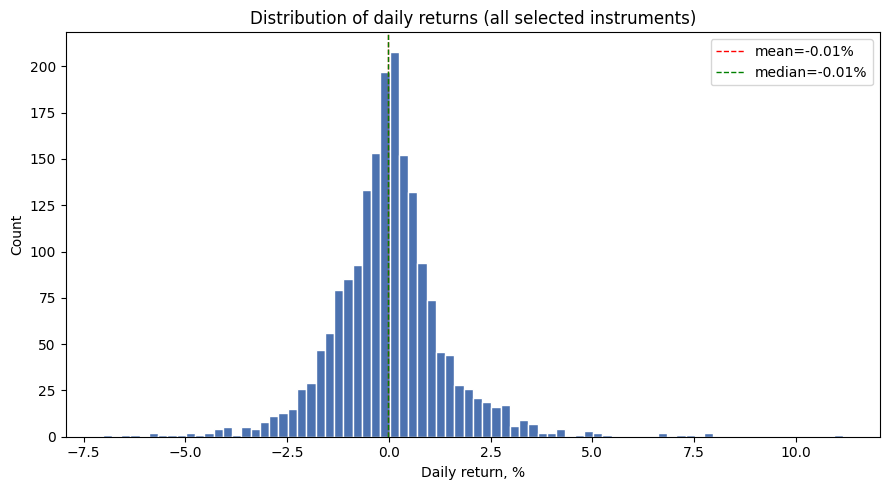

In [11]:
fig = A.fig_return_hist(df); display(fig); plt.close(fig)

**What it shows.** Pooled daily returns are roughly symmetric and centred near zero with fat tails (large moves occur more often than a normal distribution would predict) — relevant for the large-move hypothesis later.

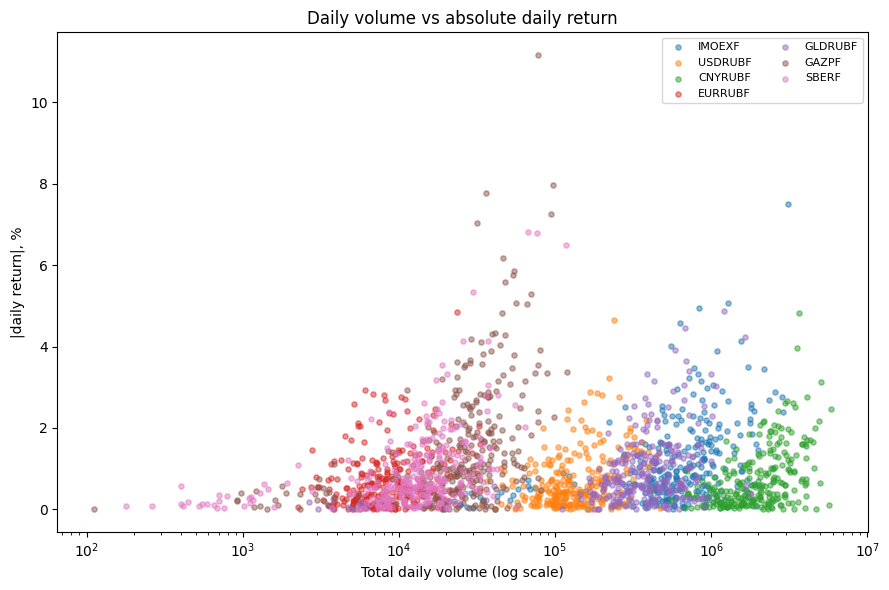

In [12]:
fig = A.fig_volume_vs_absreturn(df); display(fig); plt.close(fig)

**What it shows.** On a log-volume axis, larger absolute returns tend to coincide with higher daily volume — a visual preview of Hypothesis 2.

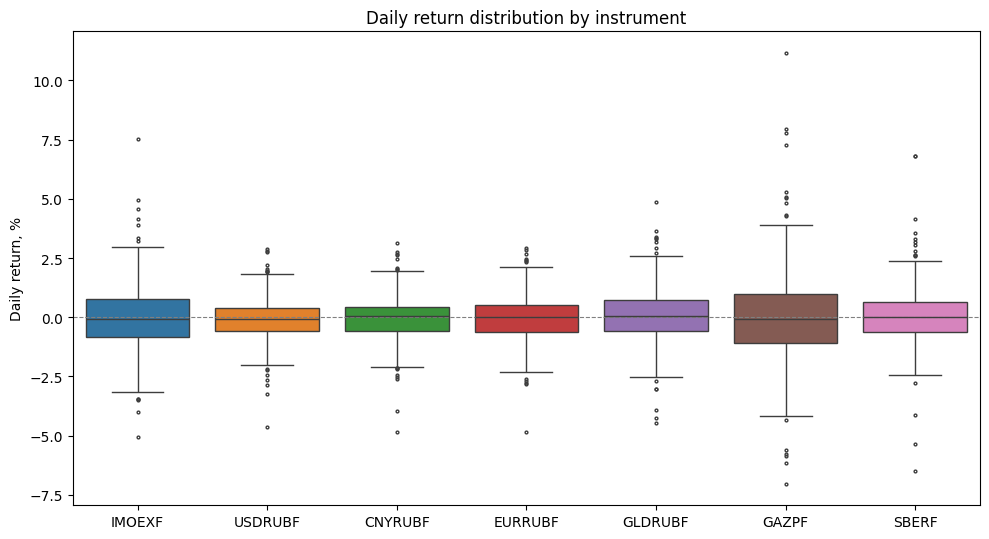

In [13]:
fig = A.fig_return_box(df); display(fig); plt.close(fig)

**What it shows.** Box widths (IQR) and whiskers rank the instruments by volatility: single-stock futures (GAZPF, SBERF) are widest, FX futures the tightest, with the index and gold in between.

## 10. Detailed Comparative Overview

Five comparative views: normalized prices, liquidity, open interest, return correlations, and intraday activity.

,mean_volume,mean_trades
symbol,,
IMOEXF,"731,038.0000","48,442.0000"
USDRUBF,"152,733.0000","22,093.0000"
CNYRUBF,"2,146,998.0000","41,477.0000"
EURRUBF,"9,598.0000","2,536.0000"
GLDRUBF,"397,767.0000","25,885.0000"
GAZPF,"30,507.0000","4,244.0000"
SBERF,"15,869.0000","3,097.0000"


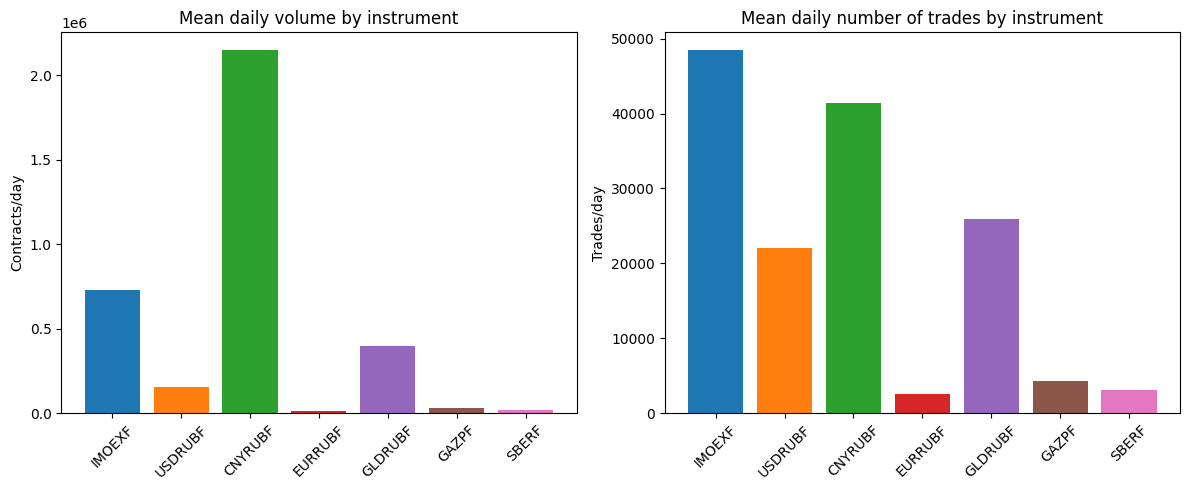

In [14]:
# (1) normalized prices are in section 9; here: liquidity comparison
fig, gtab = A.fig_liquidity_bars(df); display(gtab.round(0)); display(fig); plt.close(fig)

**What it shows.** The index and FX perpetuals dominate both average daily volume and average number of trades; the single-stock perpetuals are an order of magnitude thinner.

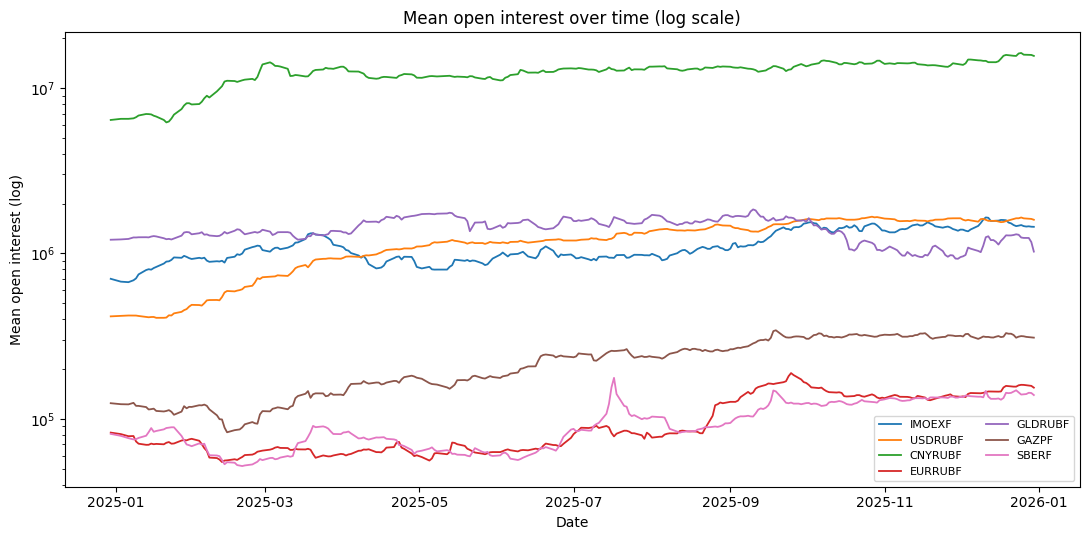

In [15]:
fig = A.fig_open_interest(df); display(fig); plt.close(fig)

**What it shows.** Open interest (log scale) is highest and steadiest for the FX and index contracts and lower for single stocks, consistent with the liquidity ranking above.

symbol,IMOEXF,USDRUBF,CNYRUBF,EURRUBF,GLDRUBF,GAZPF,SBERF
symbol,,,,,,,
IMOEXF,1.0000,-0.2600,-0.2300,-0.2400,-0.0100,0.9000,0.8600
USDRUBF,-0.2600,1.0000,0.9600,0.8900,0.5400,-0.3000,-0.2700
CNYRUBF,-0.2300,0.9600,1.0000,0.8900,0.5500,-0.2700,-0.2300
EURRUBF,-0.2400,0.8900,0.8900,1.0000,0.6000,-0.2700,-0.2400
GLDRUBF,-0.0100,0.5400,0.5500,0.6000,1.0000,-0.0800,-0.0100
GAZPF,0.9000,-0.3000,-0.2700,-0.2700,-0.0800,1.0000,0.7400
SBERF,0.8600,-0.2700,-0.2300,-0.2400,-0.0100,0.7400,1.0000


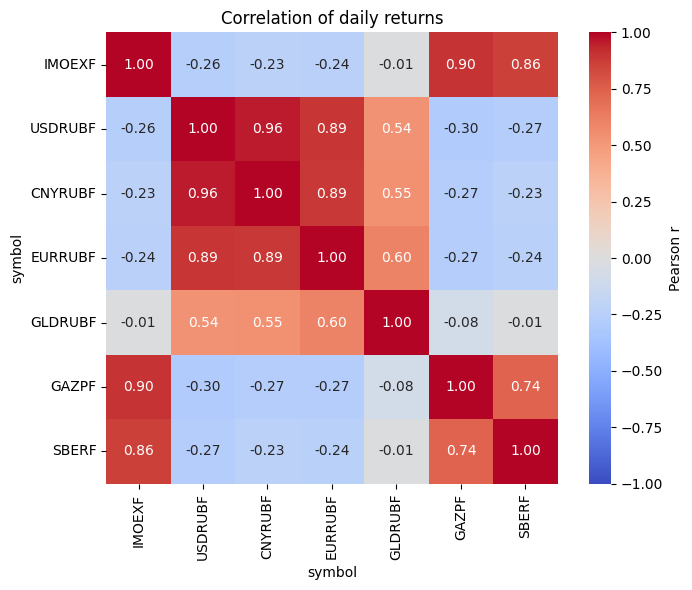

In [16]:
corr, fig = A.return_correlation(df); display(corr.round(2)); display(fig); plt.close(fig)

**What it shows.** Daily-return correlations are high among the FX perpetuals (they share the rouble as the common factor), moderate between the index and the two stocks, and low between FX and equities — i.e. the chosen instruments are genuinely diversified.

,mean_buy_share,mean_imbalance
symbol,,
IMOEXF,0.4980,0.0260
USDRUBF,0.4900,0.0300
CNYRUBF,0.4880,0.0360
EURRUBF,0.4830,0.0760
GLDRUBF,0.5050,0.0380
GAZPF,0.4910,0.0600
SBERF,0.4870,0.0580


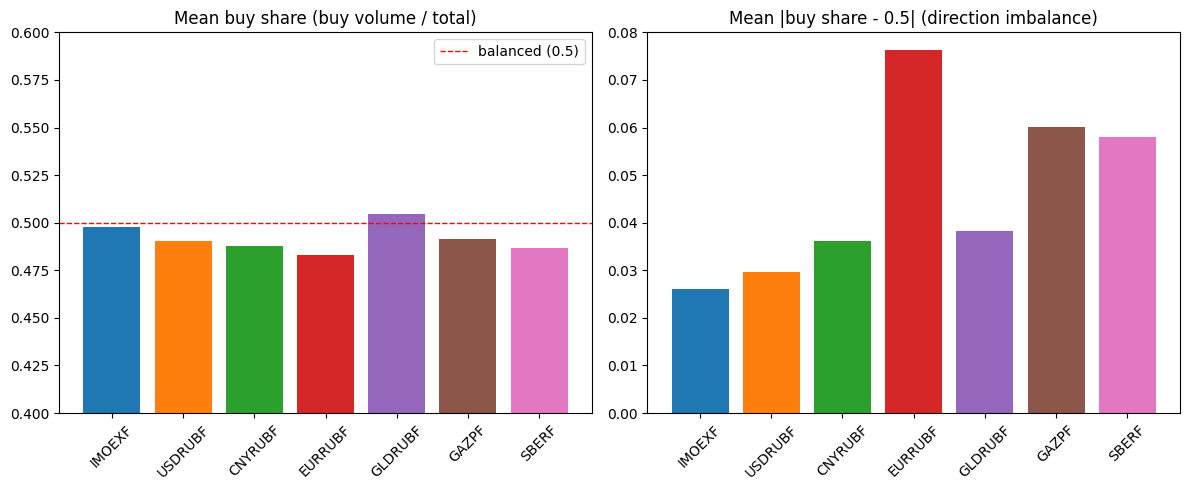

In [17]:
tab, fig = A.buysell_overview(df); display(tab.round(3)); display(fig); plt.close(fig)

**What it shows.** Average buy share sits close to 0.5 for every instrument (balanced aggressor flow), with small, instrument-specific imbalances.

,trades,volume
hour,,
8,327,3865
9,26330,327029
10,390259,7673872
11,244569,4775244
12,210749,3735584
13,184898,3310606
14,166809,2739781
15,160935,2906073
16,163589,2787363


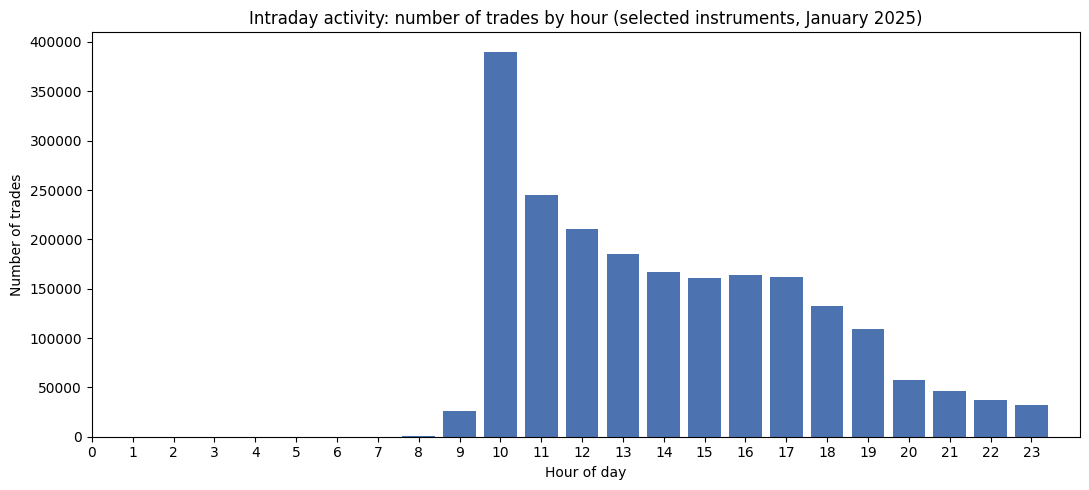

In [18]:
hourly, fig = A.hourly_activity(); display(hourly); display(fig); plt.close(fig)

**What it shows.** Intraday (January) activity is concentrated in the main daytime session, with a secondary bump during the evening session — the classic MOEX two-session trading day.

## 11. Hypothesis Testing

We test three hypotheses that go beyond a single two-group comparison. For each we
report a statistic and a figure and state honestly whether the data support it.

### Hypothesis 1 — *More liquid futures contracts have lower volatility.*
Tested across **all sufficiently-liquid contracts** (not only the seven), correlating
two liquidity measures (avg daily volume, avg daily #trades) with two volatility
measures (std of daily return, mean relative range).

Liquidity vs volatility correlations (n = 317 contracts):


,liquidity,volatility_metric,pearson_logx,spearman
0,avg_volume,volatility,0.0220,0.0030
1,avg_volume,mean_rel_range,0.0690,0.0490
2,avg_trades,volatility,-0.1030,-0.1310
3,avg_trades,mean_rel_range,-0.0830,-0.1030


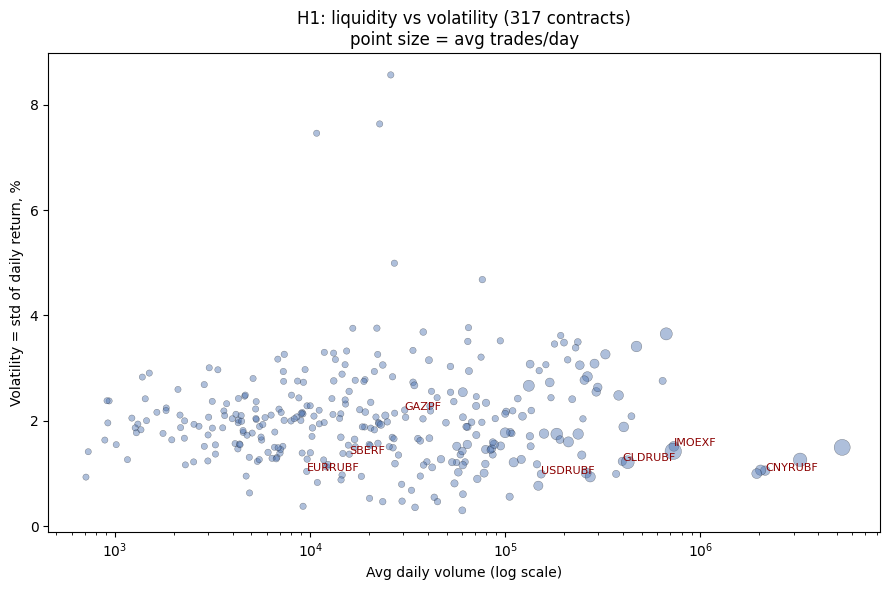

In [19]:
h1_tab, h1_corr, fig = A.hypothesis1(daily_all)
print('Liquidity vs volatility correlations (n = %d contracts):' % len(h1_tab))
display(h1_corr)
display(fig); plt.close(fig)

**Conclusion (H1): not supported.** All correlations are essentially zero (|Pearson|, |Spearman| ≤ ~0.13). In this dataset there is **no meaningful negative relationship** between liquidity and volatility across contracts — the intuitive 'more liquid ⇒ calmer' idea does not hold here. We report the result without inventing external causes.

### Hypothesis 2 — *Days with large price movements have higher trading activity.*
`large_move_day` = a day whose `|return|` is in the **top 10%** for that instrument.
We compare activity on large-move vs normal days and, to remove scale differences,
use the within-instrument **z-score** of volume with a Mann–Whitney U test.

mean                      median               \
group                large-move         normal   large-move       normal   
metric                                                                     
mean_open_pos    2,184,799.2300 2,277,396.9600 854,999.0900 940,370.0200   
num_trades          33,357.8400    19,748.3400  27,644.5000  13,680.0000   
total_volume       745,881.9800   457,158.8600 188,210.5000  98,326.5000   
volume_per_trade        14.4700        14.5100       8.6800       8.3300   

                            std                 
group                large-move         normal  
metric                                          
mean_open_pos    3,984,136.0500 4,128,776.7600  
num_trades          31,911.5300    20,860.9400  
total_volume     1,145,493.5600   780,661.3900  
volume_per_trade        15.5600        16.0700

Mann-Whitney U (z-volume, large-move > normal): {'mannwhitney_U': 248644.5, 'p_value': 4.9532608743703045e-31, 'z_vol_large_mean': 0.8561737772291387, 'z_vol_normal_mean': -0.09747518355777754}


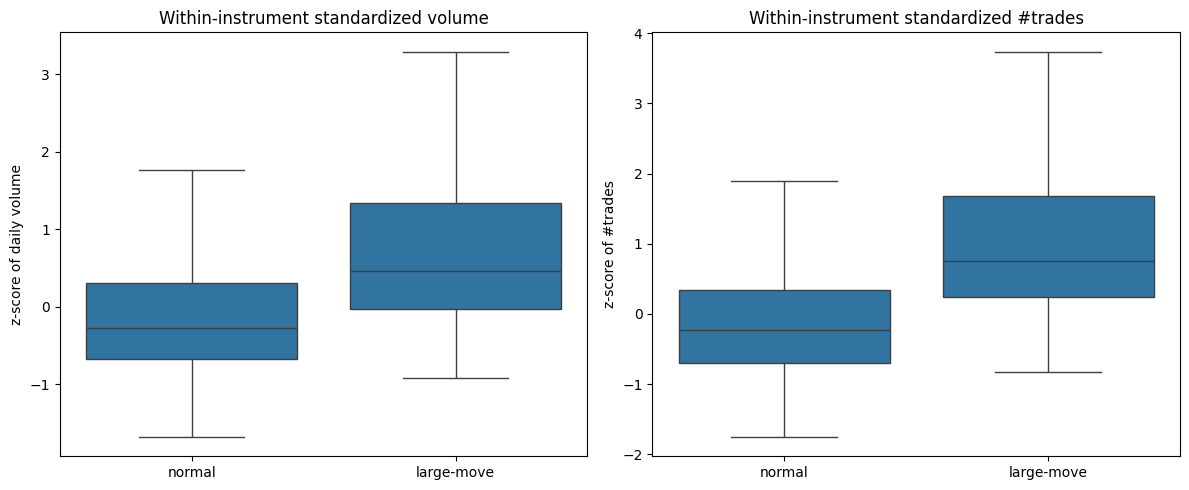

In [20]:
h2_tab, h2_test, fig = A.hypothesis2(df, q=0.90)
display(h2_tab.round(2))
print('Mann-Whitney U (z-volume, large-move > normal):', h2_test)
display(fig); plt.close(fig)

**Conclusion (H2): supported.** Mean/median volume, number of trades and volume-per-trade are all clearly higher on large-move days, and the standardized volume is significantly higher (p ≈ 5·10⁻³¹). Large price moves and high trading activity go together in these data.

### Hypothesis 3 — *Buy/sell imbalance is higher on high-volatility days.*
Same top-10% split by `|return|`, comparing `direction_imbalance` (`|buy_share − 0.5|`).

,mean,median,std,count
group,,,,
high-vol,0.0484,0.0383,0.0389,194
normal,0.0459,0.0320,0.0483,1704


Mann-Whitney U (imbalance, high-vol > normal): {'mannwhitney_U': 183506.0, 'p_value': 0.005888981209946567}


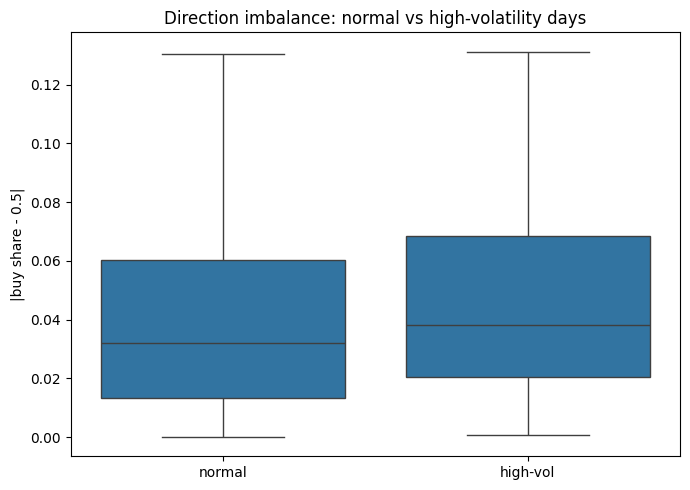

In [21]:
h3_tab, h3_test, fig = A.hypothesis3(df, q=0.90)
display(h3_tab.round(4))
print('Mann-Whitney U (imbalance, high-vol > normal):', h3_test)
display(fig); plt.close(fig)

**Conclusion (H3): supported (modestly).** Direction imbalance is higher on high-volatility days (p ≈ 0.006). On turbulent days aggressor flow leans a little more to one side, though the effect is small compared with H2.

## 12. Discussion

Putting the pieces together, the seven instruments form a clear **liquidity/volatility
ordering**: FX perpetuals are the most liquid and the calmest; single-stock perpetuals
are the thinnest and the most volatile; the index and gold sit in between. Yet *across
the broad contract universe* liquidity does **not** predict volatility (H1) — the
ordering we see among the seven is driven by **asset class**, not by liquidity per se.
Activity, however, is tightly linked to **price movement**: large-move days are
high-volume days (H2), and order flow becomes slightly more one-sided when volatility
is high (H3). The return-correlation structure confirms the instruments are
diversified (FX cluster vs equity cluster), and the data also reveal exchange
micro-structure facts — a two-session trading day and the 2025 introduction of weekend
sessions for non-FX instruments. All statements above are derived **only** from the
data; we make no claims about external (news/macro) drivers, which are not in the dataset.

## 13. Conclusion

We built, from ~404 million raw MOEX futures trades, a clean self-constructed daily
dataset and a feature set, and used them for a full EDA. Two of three hypotheses were
supported (large moves ↔ activity; imbalance ↔ volatility) and one was rejected
(liquidity ↔ volatility). The project demonstrates a memory-safe pipeline (chunked
reading, aggregation, Parquet outputs), honest data-quality reporting, comparative
visual analysis, and statistically-backed hypothesis testing.

## 14. Limitations

- **Scope:** futures only (`fut_deal`); options and the full order log (`fut_log`) were
  excluded by design. Analysis is one calendar year (2025), so seasonal claims are
  limited to a single year.
- **Perpetual instruments:** the seven analysed contracts are *evergreen* perpetual
  futures, chosen for clean year-long coverage; expiry-coded quarterly contracts (which
  roll) are summarised but not used for the time-series analysis.
- **Daily aggregation** discards intraday structure (except the separate hourly
  profile). Open interest is summarised per day (mean/max), not as an end-of-day snapshot.
- **Weekend sessions / month-boundary evening sessions** add a few extra dates for some
  instruments; returns around these are kept as-is and flagged rather than removed.
- **Hypothesis tests** are descriptive/associational, not causal; ticker→underlying
  labels follow MOEX naming conventions and should be confirmed against the official
  MOEX instrument reference.

## 15. Web Interface Description

The same content is delivered as a **Streamlit** app (`app/streamlit_app.py`) with
sidebar navigation mirroring this notebook (Abstract, Dataset, Cleaning, Statistics,
Plots, Detailed Overview, Hypotheses, Discussion). It reads the **aggregated Parquet**
files (not the raw archives), so it is lightweight. A small **FastAPI** service
(`app/api.py`) exposes the aggregated data: a `GET /data` endpoint filtering by
`symbol` + `limit` (and optional date range), `GET /symbols`, `GET /stats/{symbol}`,
and a demo `POST /data` that appends a record to a local CSV.